Found 1909 images belonging to 4 classes.
Found 433 images belonging to 4 classes.


<>:27: SyntaxWarning: invalid escape sequence '\d'
<>:27: SyntaxWarning: invalid escape sequence '\d'
C:\Users\user\AppData\Local\Temp\ipykernel_19284\3653408798.py:27: SyntaxWarning: invalid escape sequence '\d'
  "C:\\Users\\user\\Downloads\\archive\dataset_new\\train",
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


{'Closed': 0, 'Open': 1, 'no_yawn': 2, 'yawn': 3}
Epoch 1/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.6281 - loss: 0.8067 - val_accuracy: 0.7159 - val_loss: 0.4477
Epoch 2/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.7983 - loss: 0.4081 - val_accuracy: 0.6836 - val_loss: 0.5490
Epoch 3/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.8030 - loss: 0.3931 - val_accuracy: 0.6721 - val_loss: 0.5751
Epoch 4/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.7988 - loss: 0.3866 - val_accuracy: 0.7483 - val_loss: 0.3890
Epoch 5/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.8161 - loss: 0.3257 - val_accuracy: 0.7691 - val_loss: 0.3807
Epoch 6/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.8203 - loss: 0.3052 - val_accuracy: 0.7182 - val_loss: 0.3906
Epoch 7/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.8308 - loss: 0.3035 - val_accuracy: 0.6998 - val_loss: 0.5485
Epoch 8/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy

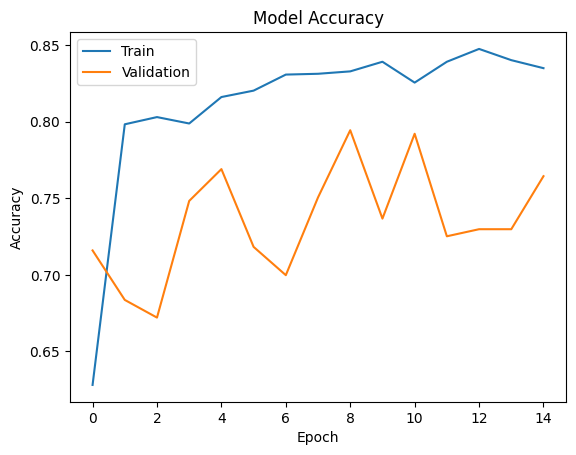

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Image settings
IMG_SIZE = 64
BATCH_SIZE = 32

# Dataset paths
TRAIN_PATH = r'dataset/train'
TEST_PATH = r'dataset/test'

# Data preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

# Train generator
train_generator = train_datagen.flow_from_directory(
    "C:\\Users\\user\\Downloads\\archive\dataset_new\\train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Test generator
validation_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    "C:\\Users\\user\\Downloads\\archive\\dataset_new\\test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print(train_generator.class_indices)

# CNN Model
model = Sequential()

# Layer 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(4, activation='softmax'))

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

# Save model
model.save('drowsiness_model.keras')

print('Model Saved Successfully')

# Accuracy Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

In [10]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# Load trained model
model = load_model('drowsiness_model.keras')

# Load Haar Cascade files
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_eye.xml'
)

# Start webcam
cap = cv2.VideoCapture(0)

IMG_SIZE = 64

while True:

    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect faces
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:

        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)

        roi_gray = gray[y:y+h, x:x+w]
        roi_color = frame[y:y+h, x:x+w]

        # Detect eyes
        eyes = eye_cascade.detectMultiScale(roi_gray)

        for (ex, ey, ew, eh) in eyes:

            eye = roi_color[ey:ey+eh, ex:ex+ew]

            # Resize image
            eye = cv2.resize(eye, (IMG_SIZE, IMG_SIZE))

            # Normalize
            eye = eye / 255.0

            # Reshape for CNN
            eye = np.reshape(eye, (1, IMG_SIZE, IMG_SIZE, 3))

            # Prediction
            prediction = model.predict(eye, verbose=0)

            # Label
            predicted_class = np.argmax(prediction)

            if predicted_class == 0:
                label = "Closed Eyes"
                color = (0,0,255)

            elif predicted_class == 1:
                label = "Open Eyes"
                color = (0,255,0)

            elif predicted_class == 2:
                label = "No Yawn"
                color = (255,255,0)

            else:
                label = "Yawning"
                color = (255,0,255)

            # Show text
            cv2.putText(
                frame,
                label,
                (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                color,
                2
            )

            # Eye rectangle
            cv2.rectangle(
                roi_color,
                (ex, ey),
                (ex+ew, ey+eh),
                color,
                2
            )

    # Show webcam
    cv2.imshow("Drowsiness Detection", frame)

    # Press q to exit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

In [11]:
print(train_generator.class_indices)

{'Closed': 0, 'Open': 1, 'no_yawn': 2, 'yawn': 3}


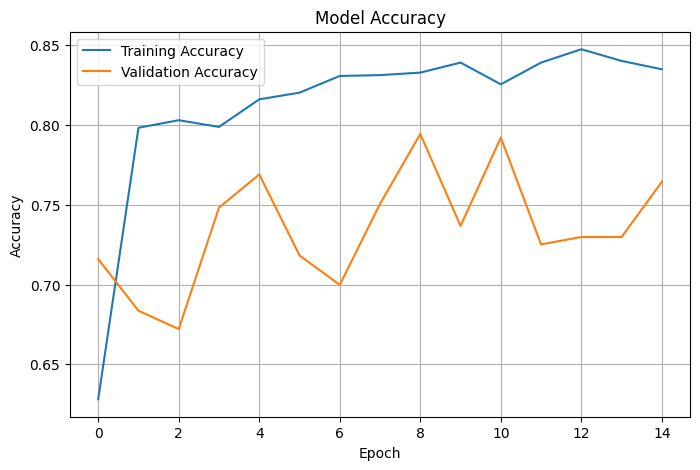

In [12]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

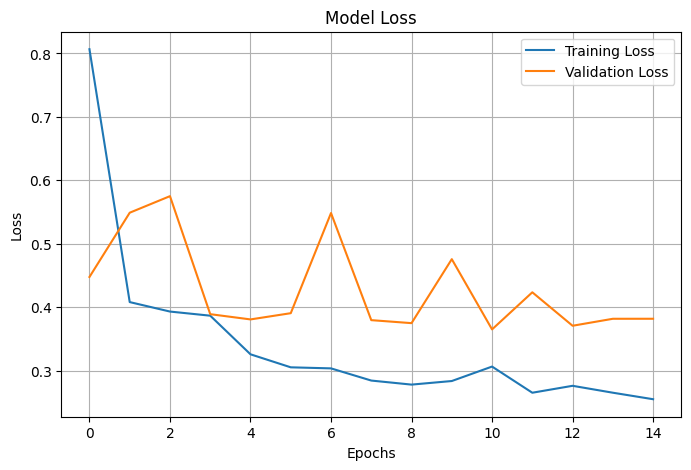

In [13]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


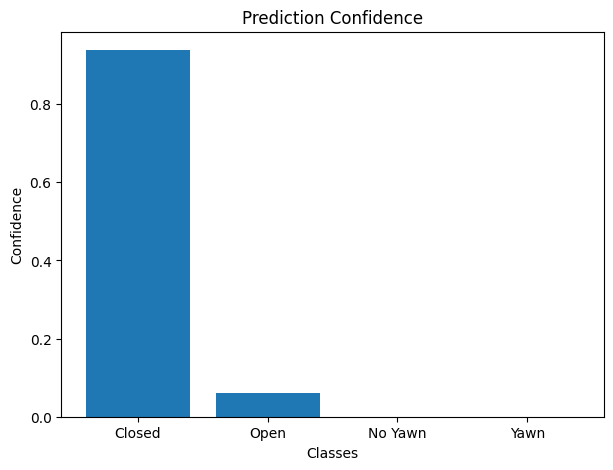

In [14]:
import numpy as np

classes = ['Closed', 'Open', 'No Yawn', 'Yawn']

prediction = model.predict(eye)[0]

plt.figure(figsize=(7,5))
plt.bar(classes, prediction)

plt.title('Prediction Confidence')
plt.xlabel('Classes')
plt.ylabel('Confidence')
plt.show()

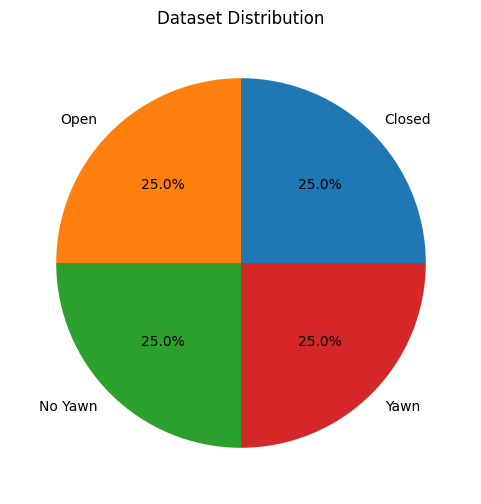

In [15]:
labels = ['Closed', 'Open', 'No Yawn', 'Yawn']
values = [726, 726, 726, 726]   # change according to dataset

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title('Dataset Distribution')
plt.show()

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step


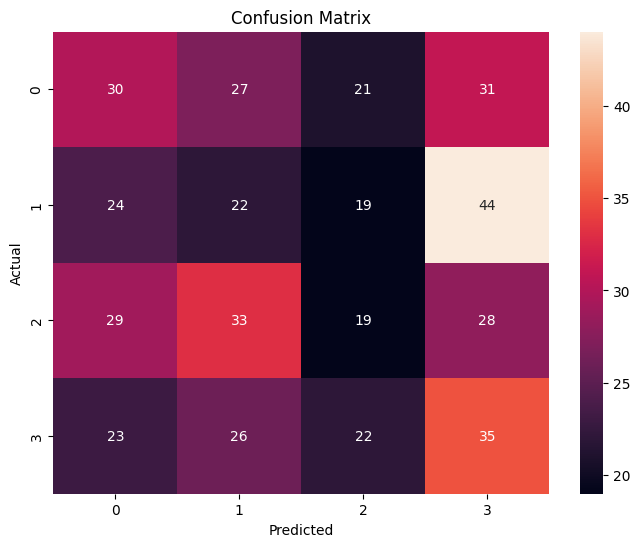

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

Y_pred = model.predict(validation_generator)
y_pred = np.argmax(Y_pred, axis=1)

cm = confusion_matrix(validation_generator.classes, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

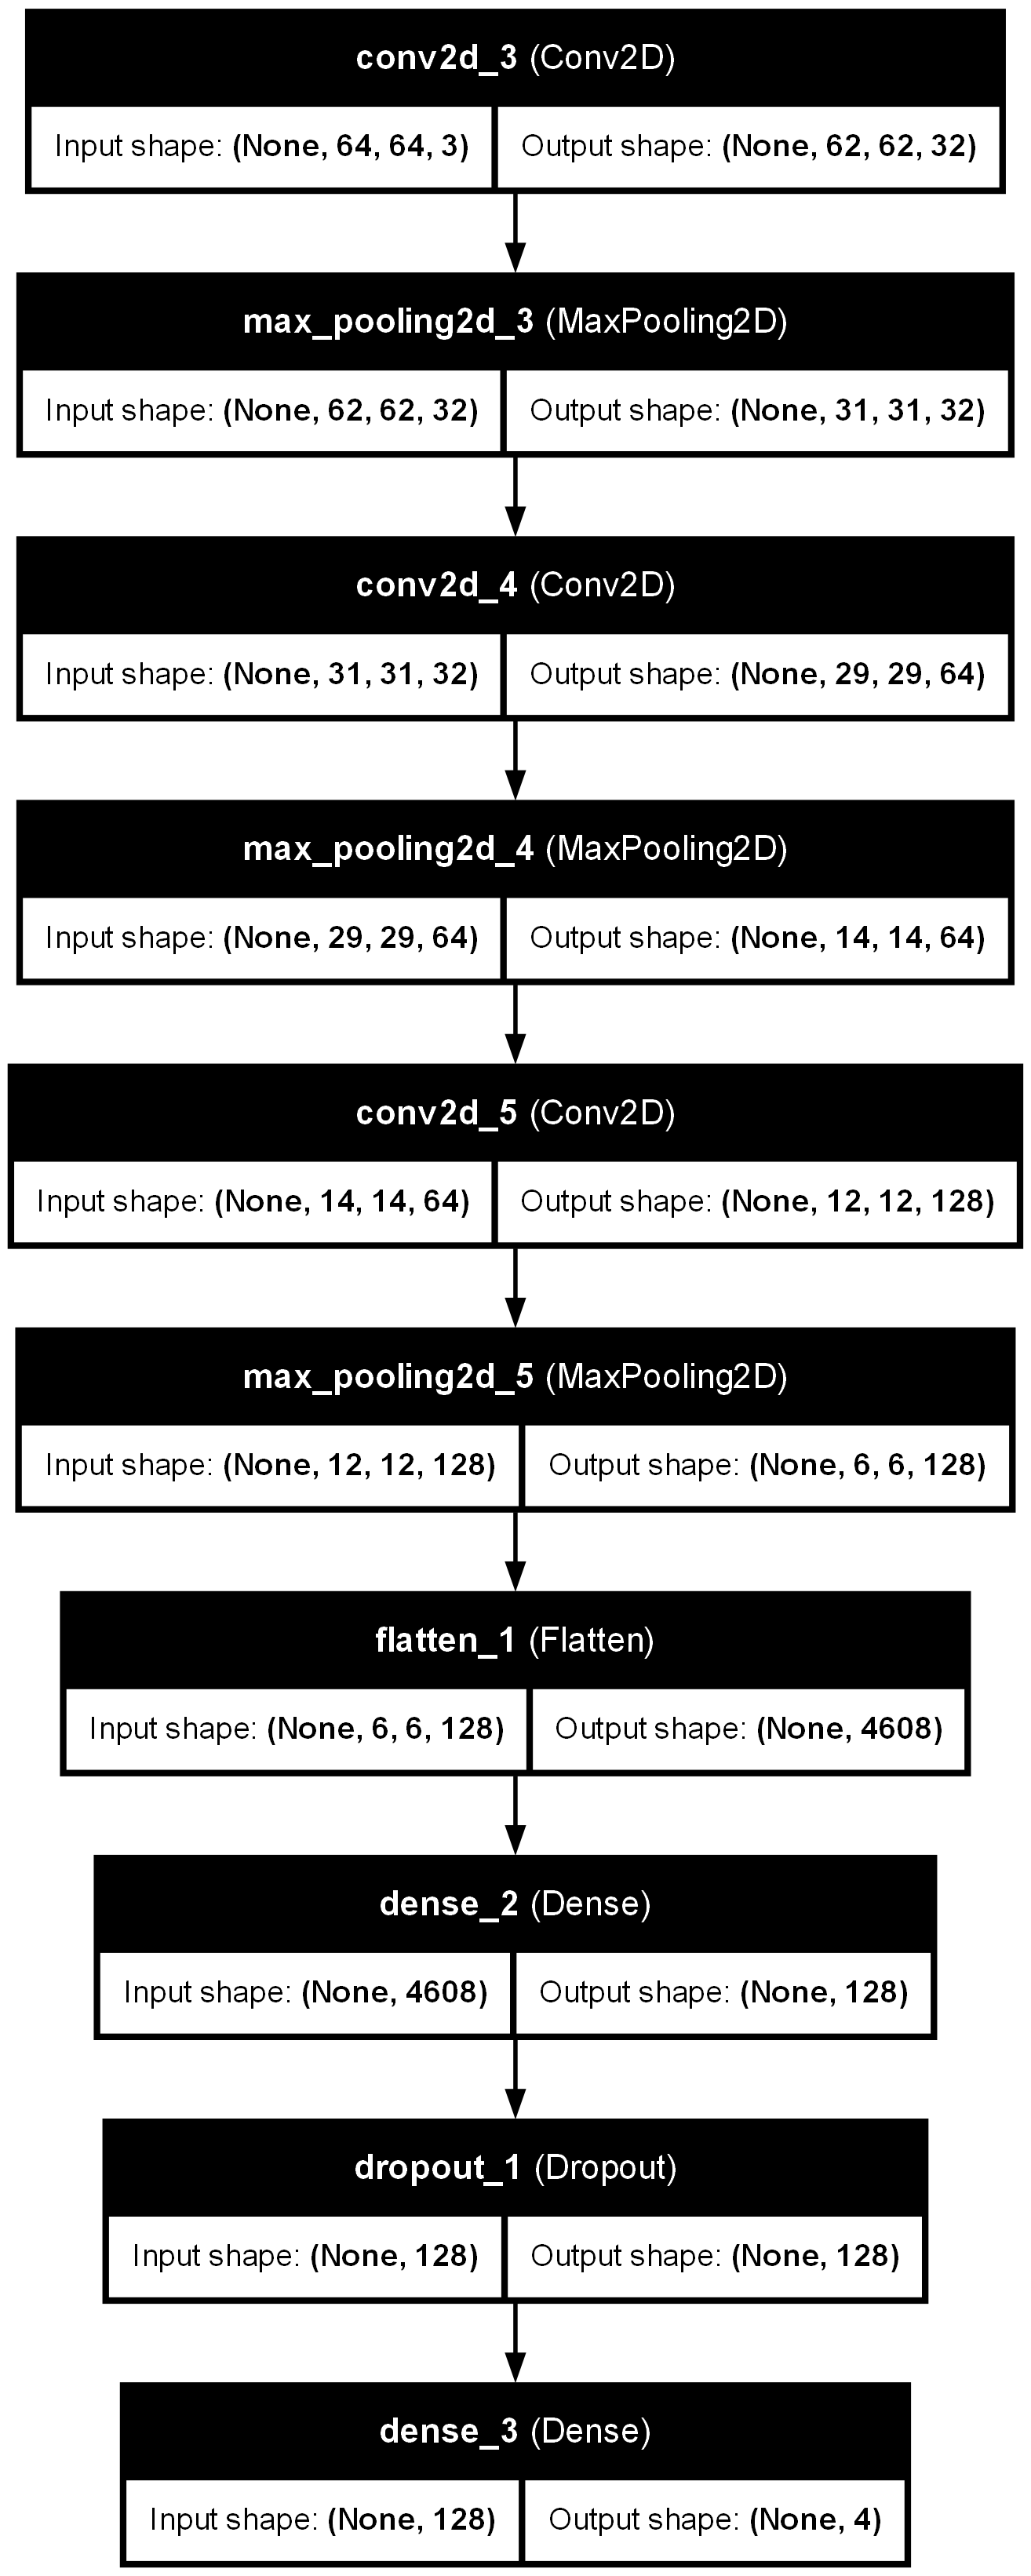

In [17]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file='cnn_model.png',
    show_shapes=True,
    show_layer_names=True
)

In [18]:
import winsound
winsound.Beep(1000, 500)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


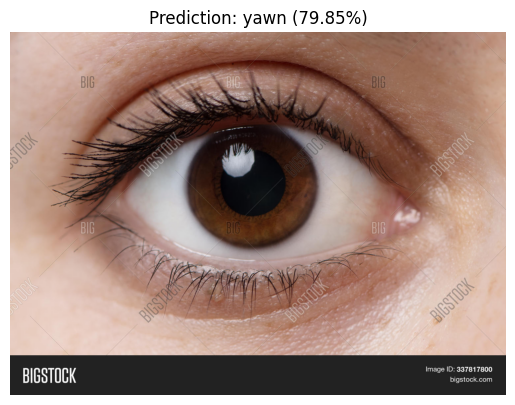

Prediction: yawn
Confidence: 79.84566


In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Load trained model
model = load_model('drowsiness_model.keras')

# Class labels
classes = ['Closed', 'Open', 'no_yawn', 'yawn']

# Image size
IMG_SIZE = 64

# Upload image path
image_path = r"C:\\Users\\user\\Downloads\\337817800.jpg"  # change image name if needed

# Read image
img = cv2.imread(image_path)

# Check image loaded
if img is None:
    print("Image not found!")
    exit()

# Resize image
img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

# Normalize
img_normalized = img_resized / 255.0

# Reshape for CNN
img_reshape = np.reshape(img_normalized, (1, IMG_SIZE, IMG_SIZE, 3))

# Prediction
prediction = model.predict(img_reshape)

# Get highest probability class
predicted_class = np.argmax(prediction)

# Label
label = classes[predicted_class]

# Confidence
confidence = np.max(prediction) * 100

# Show image
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f'Prediction: {label} ({confidence:.2f}%)')
plt.axis('off')
plt.show()

# Print result
print("Prediction:", label)
print("Confidence:", confidence)